<a href="https://colab.research.google.com/github/sandya-1210/Predictive_Analytics/blob/main/studentplacementprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

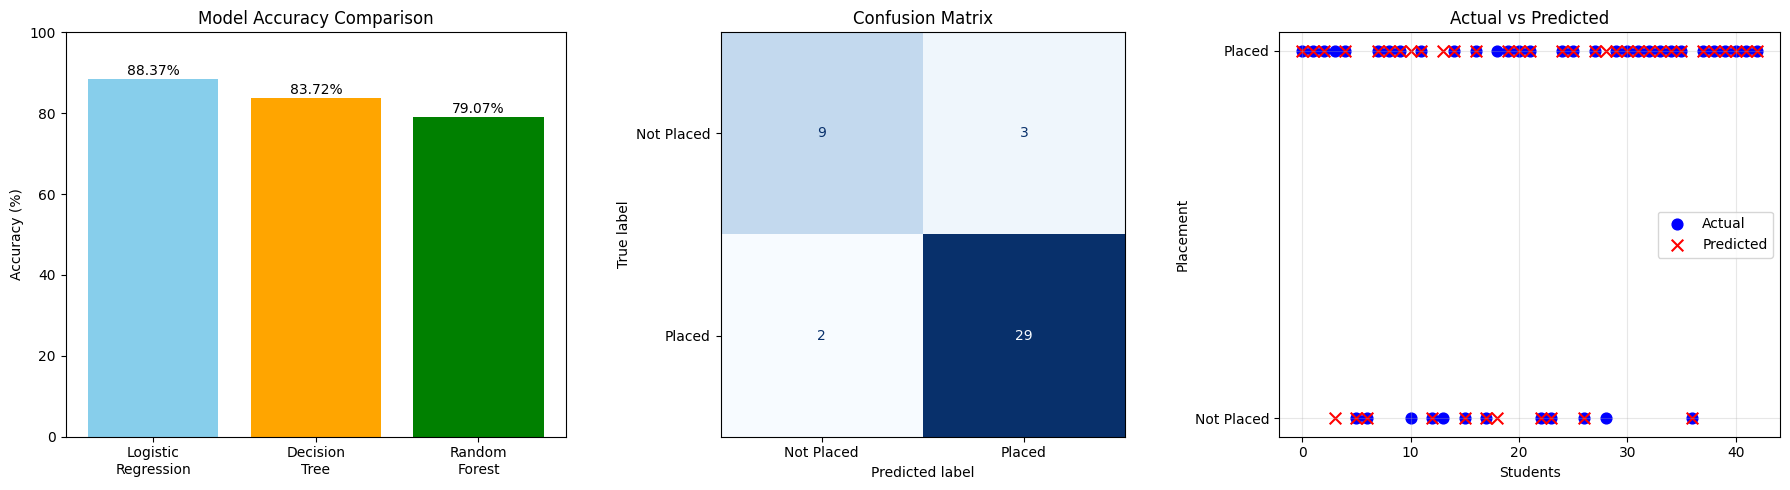

BEST MODEL : Logistic Regression
ACCURACY   : 88.37 %


In [8]:
# ==========================================================
# VISUALIZATION OF STUDENT PLACEMENT PREDICTION
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

# ----------------------------------------------------------
# Select Best Model
# ----------------------------------------------------------

if lr_acc >= dt_acc and lr_acc >= rf_acc:
    best_model = lr
    prediction = lr_pred
    model_name = "Logistic Regression"

elif dt_acc >= lr_acc and dt_acc >= rf_acc:
    best_model = dt
    prediction = dt_pred
    model_name = "Decision Tree"

else:
    best_model = rf
    prediction = rf_pred
    model_name = "Random Forest"

# ==========================================================
# CREATE 3 FIGURES
# ==========================================================

plt.figure(figsize=(18,5))

# ==========================================================
# GRAPH 1 : MODEL ACCURACY
# ==========================================================

plt.subplot(1,3,1)

models = ["Logistic\nRegression",
          "Decision\nTree",
          "Random\nForest"]

accuracy = [lr_acc*100,
            dt_acc*100,
            rf_acc*100]

bars = plt.bar(models,
               accuracy,
               color=["skyblue","orange","green"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.ylim(0,100)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y+1,
             f"{y:.2f}%",
             ha='center')

# ==========================================================
# GRAPH 2 : CONFUSION MATRIX
# ==========================================================

plt.subplot(1,3,2)

cm = confusion_matrix(y_test, prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed","Placed"]
)

disp.plot(ax=plt.gca(), cmap="Blues", colorbar=False)

plt.title("Confusion Matrix")

# ==========================================================
# GRAPH 3 : ACTUAL VS PREDICTED
# ==========================================================

plt.subplot(1,3,3)

x = np.arange(len(y_test))

plt.scatter(
    x,
    y_test,
    color="blue",
    label="Actual",
    s=60
)

plt.scatter(
    x,
    prediction,
    color="red",
    marker="x",
    label="Predicted",
    s=70
)

plt.yticks([0,1],["Not Placed","Placed"])

plt.xlabel("Students")

plt.ylabel("Placement")

plt.title("Actual vs Predicted")

plt.legend()

plt.grid(alpha=0.3)

# ==========================================================

plt.tight_layout()

plt.show()

# ==========================================================
# PRINT RESULT
# ==========================================================

print("="*50)
print("BEST MODEL :", model_name)
print("ACCURACY   :", round(max(lr_acc,dt_acc,rf_acc)*100,2),"%")
print("="*50)